In [ ]:
import sys
import os

sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../"))

# from desc import set_device
# set_device("gpu")

In [4]:
import numpy as np
np.set_printoptions(linewidth=np.inf, precision=4, suppress=True, threshold=sys.maxsize)
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.graph_objects as go
import functools
import scipy

In [5]:
import desc

from desc.basis import *
from desc.backend import *
from desc.compute import *
from desc.coils import *
from desc.equilibrium import *
from desc.examples import *
from desc.grid import *
from desc.geometry import *
from desc.io import *

from desc.objectives import *
from desc.objectives.objective_funs import *
from desc.objectives.getters import *
from desc.objectives.normalization import compute_scaling_factors
from desc.objectives.utils import *
from desc.optimize._constraint_wrappers import *

from desc.transform import Transform
from desc.plotting import *
from desc.optimize import *
from desc.perturbations import *
from desc.profiles import *
from desc.compat import *
from desc.utils import *
from desc.magnetic_fields import *
from desc.particles import *
from diffrax import *

from desc.__main__ import main
from desc.vmec_utils import vmec_boundary_subspace
from desc.input_reader import InputReader
from desc.continuation import solve_continuation_automatic
from desc.compute.data_index import register_compute_fun
from desc.optimize.utils import solve_triangular_regularized

print_backend_info()

DESC version=0.17.0+4.g5ce224c4b.
Using JAX backend: jax version=0.6.2, jaxlib version=0.6.2, dtype=float64.
Using device: CPU, with 20.38 GB available memory.


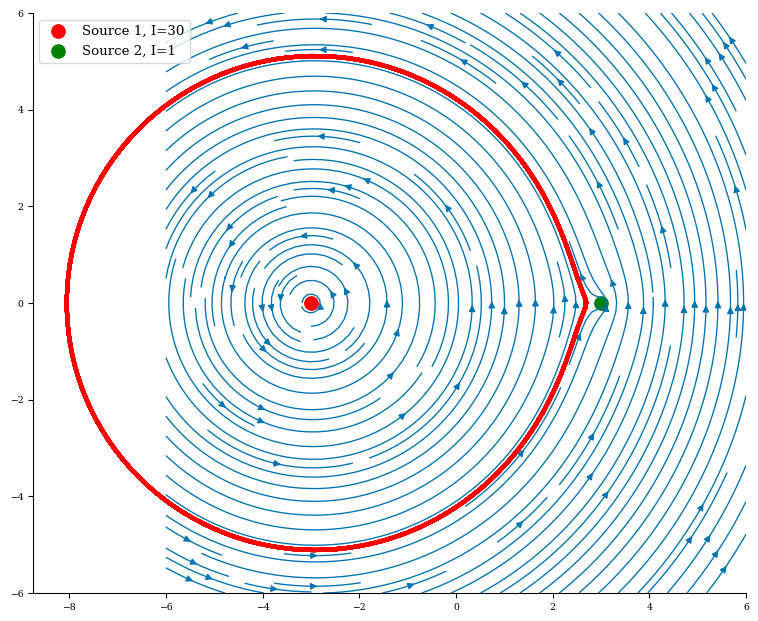

In [12]:
def field_from_current(x, xc=np.array([0, 0]), I=10):
    r = np.sqrt((x[0] - xc[0]) ** 2 + (x[1] - xc[1]) ** 2)
    B = I / (2 * np.pi * r)
    return B * np.array([- (x[1] - xc[1]) / r, (x[0] - xc[0]) / r])


def sum_field(x, sources, currents):
    total_field = np.zeros_like(x)
    for xc, I in zip(sources, currents):
        total_field += field_from_current(x, xc=xc, I=I)
    return total_field


x = np.linspace(-6, 6, 100)
y = np.linspace(-6, 6, 100)
X, Y = np.meshgrid(x, y)
source1 = np.array([-3, 0])
source2 = np.array([3, 0])
I1 = 30
I2 = 1
field = field_from_current(np.array([X, Y]), xc=source1, I=I1)
field2 = field_from_current(np.array([X, Y]), xc=source2, I=I2)
out = scipy.integrate.solve_ivp(
    lambda t, y: sum_field(
        y, sources=[source1, source2], currents=[I1, I2]
    ),
    [0, 500],
    [2.7, 0],
    t_eval=np.linspace(0, 500, 1000),
    rtol=1e-8,
    atol=1e-8,
)
plt.figure(figsize=(8, 8))
plt.scatter(source1[0], source1[1], color="red", s=100, label=f"Source 1, I={I1}")
plt.scatter(source2[0], source2[1], color="green", s=100, label=f"Source 2, I={I2}")
plt.streamplot(X, Y, field[0]+field2[0], field[1]+field2[1], density=2)
plt.plot(out.y[0], out.y[1], color="red", lw=3)
plt.legend()
plt.gca().set_aspect("equal")

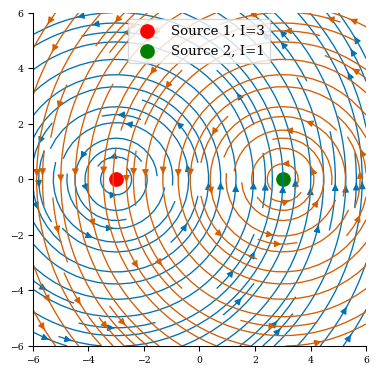

In [27]:
plt.scatter(source1[0], source1[1], color="red", s=100, label=f"Source 1, I={I1}")
plt.scatter(source2[0], source2[1], color="green", s=100, label=f"Source 2, I={I2}")
plt.streamplot(X, Y, field[0], field[1], density=1)
plt.streamplot(X, Y, field2[0], field2[1], density=1)
plt.legend()
plt.gca().set_aspect("equal")

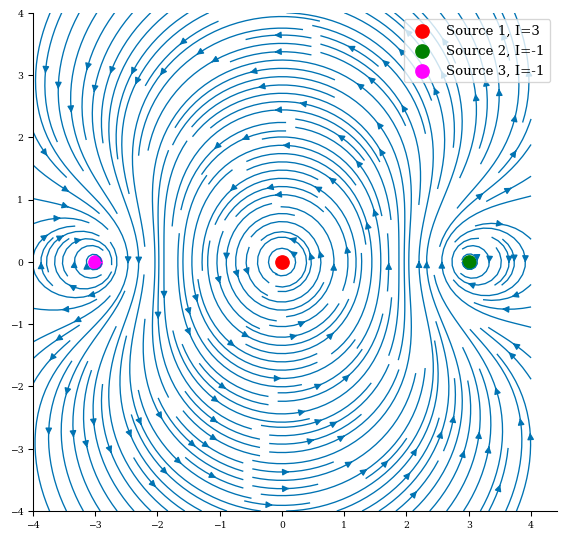

In [12]:
def field_from_current(x, xc=np.array([0, 0]), I=10):
    r = np.sqrt((x[0] - xc[0]) ** 2 + (x[1] - xc[1]) ** 2)
    B = I / (2 * np.pi * r)
    return B * np.array([-(x[1] - xc[1]) / r, (x[0] - xc[0]) / r])

def sum_field(x, sources, currents):
    total_field = np.zeros_like(x)
    for xc, I in zip(sources, currents):
        total_field += field_from_current(x, xc=xc, I=I)
    return total_field

max = 4
x = np.linspace(-max, max, 100)
y = np.linspace(-max, max, 100)
X, Y = np.meshgrid(x, y)
source1 = np.array([0, 0])
source2 = np.array([3, 0])
source3 = np.array([-3, 0])
I1 = 3
I2 = -1
I3 = -1
field = field_from_current(np.array([X, Y]), xc=source1, I=I1)
field2 = field_from_current(np.array([X, Y]), xc=source2, I=I2)
field3 = field_from_current(np.array([X, Y]), xc=source3, I=I3)
out = scipy.integrate.solve_ivp(
    lambda t, y: sum_field(y, sources=[source1, source2, source3], currents=[I1, I2, I3]),
    [0, 50],
    [2, 0],
    t_eval=np.linspace(0, 50, 1000),
    rtol=1e-8, atol=1e-8,
)
plt.figure(figsize=(6, 6))
plt.scatter(source1[0], source1[1], color="red", s=100, label=f"Source 1, I={I1}")
plt.scatter(source2[0], source2[1], color="green", s=100, label=f"Source 2, I={I2}")
plt.scatter(source3[0], source3[1], color="magenta", s=100, label=f"Source 3, I={I3}")
plt.streamplot(
    X, Y, field[0] + field2[0] + field3[0], field[1] + field2[1] + field3[1], density=2
)
# plt.plot(out.y[0], out.y[1], color="red", lw=3)
plt.legend(loc="upper right")
plt.gca().set_aspect("equal")